In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf
import shap

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Ищем корень проекта
base_dir = None
for p in ["../../data/processed", "../data/processed", "data/processed"]:
    if os.path.exists(p):
        base_dir = p
        break

macro_path = os.path.join(base_dir, "merged_macro.parquet")
df_macro = pd.read_parquet(macro_path)

In [14]:
df_macro

,region_name,mun_district,municipality,year,Population,GAP,Avg_Salary,Employment,Street_Length,Land_Area,RTA_dead,RTA_serious,RTA_minor,total_dtp,severe_dtp,dtp_severe_share,dtp_per_10k,severe_per_10k
0,Алтайский край,Город Барнаул,Город Барнаул,2014,697.7,125.7,26521.7,169790.0,684.0,93950.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Алтайский край,Город Барнаул,Город Барнаул,2015,699.9,143.4,27433.7,167108.0,684.0,93950.0,46.0,323.0,1236.0,NaN,NaN,NaN,NaN,NaN
2,Алтайский край,Город Барнаул,Город Барнаул,2016,699.2,150.1,28937.0,163524.0,693.0,93950.0,31.0,300.0,1175.0,NaN,NaN,NaN,NaN,NaN
3,Алтайский край,Город Барнаул,Город Барнаул,2017,697.2,147.0,31136.9,156695.0,1358.5,93950.0,39.0,330.0,1035.0,NaN,NaN,NaN,NaN,NaN
4,Алтайский край,Город Барнаул,Город Барнаул,2018,696.6,169.0,34761.1,156500.0,1359.3,93950.0,39.0,294.0,989.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Ярославская область,Город Ярославль,Город Ярославль,2019,609.1,295.1,43551.4,166816.0,757.3,21326.0,24.0,166.0,707.0,897.0,190.0,0.211817,14.726646,3.119356
996,Ярославская область,Город Ярославль,Город Ярославль,2020,604.9,297.9,45901.8,164490.0,757.3,21326.0,32.0,152.0,555.0,745.0,185.0,0.248322,12.316085,3.058357
997,Ярославская область,Город Ярославль,Город Ярославль,2021,597.7,376.3,50258.1,163927.0,760.1,21452.5,18.0,105.0,487.0,598.0,120.0,0.200669,10.005019,2.007696
998,Ярославская область,Город Ярославль,Город Ярославль,2022,573.3,393.4,56175.5,162082.0,761.0,21452.5,18.0,124.0,409.0,545.0,144.0,0.264220,9.506367,2.511774


In [3]:
df_macro.columns

Index(['region_name', 'mun_district', 'municipality', 'year', 'Population',
       'GAP', 'Avg_Salary', 'Employment', 'Street_Length', 'Land_Area',
       'RTA_dead', 'RTA_serious', 'RTA_minor', 'total_dtp', 'severe_dtp',
       'dtp_severe_share', 'dtp_per_10k', 'severe_per_10k'],
      dtype='object')

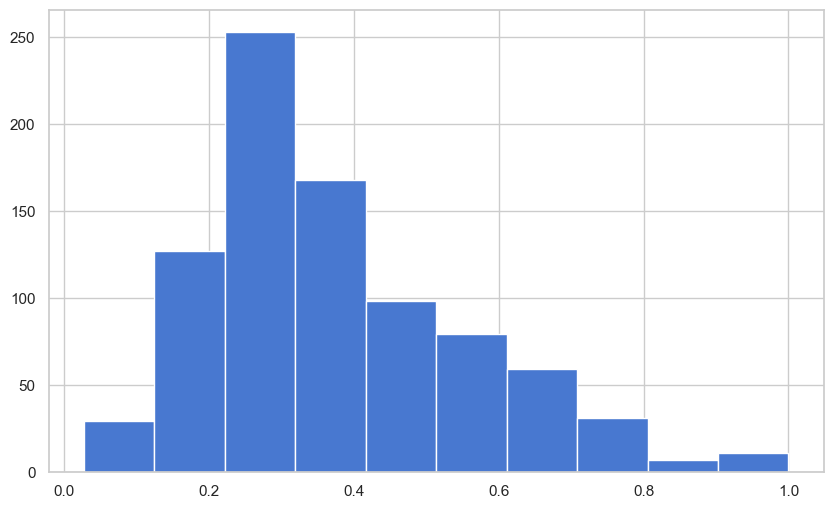

In [13]:
df_macro['dtp_severe_share'].hist();

In [4]:
df = df_macro.dropna(subset=['total_dtp']).copy()

In [5]:
df['log_Salary'] = np.log(df['Avg_Salary'] + 1)
df['log_GAP'] = np.log(df['GAP'] + 1)
df['log_Population'] = np.log(df['Population'] + 1)

print(f"Строк: {df.shape[0]}. Годы: {df['year'].min()} - {df['year'].max()}")

Строк: 862. Годы: 2015 - 2023


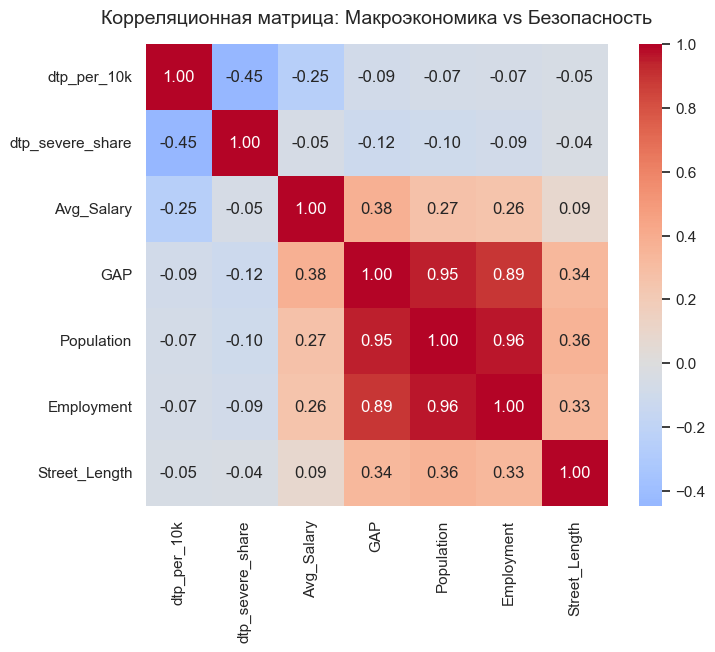

In [6]:
corr_cols = [
    'dtp_per_10k',       # Частота ДТП
    'dtp_severe_share',  # Доля тяжелых
    'Avg_Salary',        # Зарплата
    'GAP',               # ВВП (ВРП)
    'Population',        # Население
    'Employment',        # Занятость
    'Street_Length'      # Длина улиц
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Корреляционная матрица: Макроэкономика vs Безопасность", fontsize=14, pad=15)
plt.show()

In [7]:
print(corr_matrix)

                  dtp_per_10k  dtp_severe_share  Avg_Salary       GAP  \
dtp_per_10k          1.000000         -0.449374   -0.250221 -0.088601   
dtp_severe_share    -0.449374          1.000000   -0.054263 -0.116751   
Avg_Salary          -0.250221         -0.054263    1.000000  0.381564   
GAP                 -0.088601         -0.116751    0.381564  1.000000   
Population          -0.070562         -0.103191    0.267673  0.948207   
Employment          -0.067097         -0.089496    0.255713  0.891035   
Street_Length       -0.052184         -0.039926    0.088131  0.336047   

                  Population  Employment  Street_Length  
dtp_per_10k        -0.070562   -0.067097      -0.052184  
dtp_severe_share   -0.103191   -0.089496      -0.039926  
Avg_Salary          0.267673    0.255713       0.088131  
GAP                 0.948207    0.891035       0.336047  
Population          1.000000    0.963835       0.360644  
Employment          0.963835    1.000000       0.333170  
Street_Le

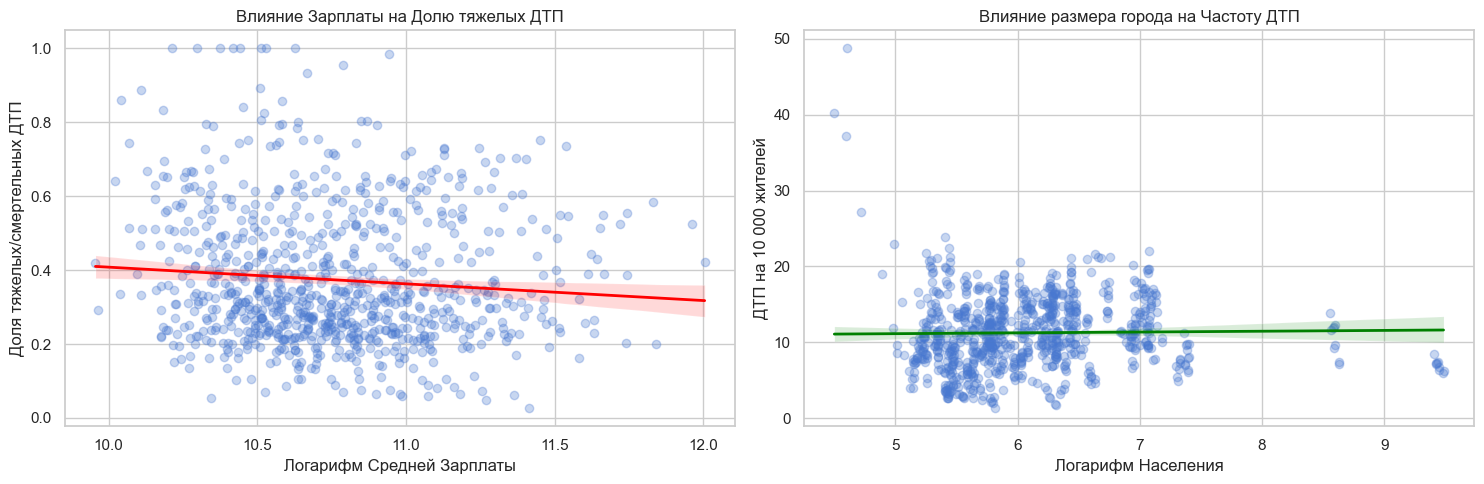

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(
    data=df, 
    x='log_Salary', 
    y='dtp_severe_share', 
    scatter_kws={'alpha': 0.3}, 
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Влияние Зарплаты на Долю тяжелых ДТП')
axes[0].set_xlabel('Логарифм Средней Зарплаты')
axes[0].set_ylabel('Доля тяжелых/смертельных ДТП')

sns.regplot(
    data=df, 
    x='log_Population', 
    y='dtp_per_10k', 
    scatter_kws={'alpha': 0.3}, 
    line_kws={'color': 'green', 'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Влияние размера города на Частоту ДТП')
axes[1].set_xlabel('Логарифм Населения')
axes[1].set_ylabel('ДТП на 10 000 жителей')

plt.tight_layout()
plt.show()

In [9]:
print("Зависимая переменная: Доля тяжелых ДТП (dtp_severe_share)")

formula = 'dtp_severe_share ~ log_Salary + log_GAP + log_Population + Street_Length'

model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

Зависимая переменная: Доля тяжелых ДТП (dtp_severe_share)
                            OLS Regression Results                            
Dep. Variable:       dtp_severe_share   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     20.27
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           5.75e-16
Time:                        16:43:57   Log-Likelihood:                 285.63
No. Observations:                 862   AIC:                            -561.3
Df Residuals:                     857   BIC:                            -537.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [10]:
from linearmodels.panel import PanelOLS

df_panel = df.copy()

df_panel['GAP_per_capita'] = df_panel['GAP'] / df_panel['Population']
df_panel['log_GAP_pc'] = np.log(df_panel['GAP_per_capita'] + 1)

df_panel = df_panel.set_index(['municipality', 'year'])

formula_panel = 'dtp_severe_share ~ 1 + log_Salary + log_GAP_pc + EntityEffects'

model_fe = PanelOLS.from_formula(formula_panel, data=df_panel)
res_fe = model_fe.fit(cov_type='robust')

print(res_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       dtp_severe_share   R-squared:                        0.0394
Estimator:                   PanelOLS   R-squared (Between):             -0.0072
No. Observations:                 862   R-squared (Within):               0.0394
Date:                Tue, Apr 07 2026   R-squared (Overall):              0.0022
Time:                        16:43:58   Log-likelihood                    953.38
Cov. Estimator:                Robust                                           
                                        F-statistic:                      15.686
Entities:                          96   P-value                           0.0000
Avg Obs:                       8.9792   Distribution:                   F(2,764)
Min Obs:                       7.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             13.527
                            

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

In [16]:
df_ml = df_macro.dropna(subset=['total_dtp', 'Avg_Salary']).copy()

target_col = 'dtp_severe_share'
features_to_drop = [
    'region_name', 'mun_district', 'municipality', 'year',
    'RTA_dead', 'RTA_serious', 'RTA_minor', 
    'total_dtp', 'severe_dtp', 'dtp_per_10k', 'severe_per_10k',
    'dtp_severe_share' # Сам таргет
]

# Оставляем только чистую экономику и инфраструктуру
X = df_ml.drop(columns=[c for c in features_to_drop if c in df_ml.columns])
y = df_ml[target_col]

print(f"Размер выборки: {X.shape[0]} строк")
print(f"Фичи для анализа ({X.shape[1]} шт.): {list(X.columns)}")

Размер выборки: 862 строк
Фичи для анализа (6 шт.): ['Population', 'GAP', 'Avg_Salary', 'Employment', 'Street_Length', 'Land_Area']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
model_macro = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100 # Выводим лог каждые 100 шагов
)

print("\nОбучение модели...")
model_macro.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=20)


Обучение модели...
0:	learn: 0.1788201	test: 0.1816540	best: 0.1816540 (0)	total: 145ms	remaining: 1m 12s
100:	learn: 0.1047938	test: 0.1299025	best: 0.1299025 (100)	total: 236ms	remaining: 930ms
200:	learn: 0.0817357	test: 0.1171603	best: 0.1171603 (200)	total: 318ms	remaining: 472ms
300:	learn: 0.0658419	test: 0.1089692	best: 0.1088792 (298)	total: 406ms	remaining: 269ms
400:	learn: 0.0560258	test: 0.1043773	best: 0.1043773 (400)	total: 511ms	remaining: 126ms
499:	learn: 0.0486815	test: 0.1011768	best: 0.1011768 (499)	total: 617ms	remaining: 0us

bestTest = 0.1011768302
bestIteration = 499



In [19]:
feature_importances = model_macro.get_feature_importance()
imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': feature_importances
}).sort_values(by='Importance (%)', ascending=False)

print(imp_df.to_string(index=False))

      Feature  Importance (%)
   Employment       25.312126
    Land_Area       25.293261
Street_Length       14.254682
   Population       14.198326
          GAP       13.743250
   Avg_Salary        7.198356


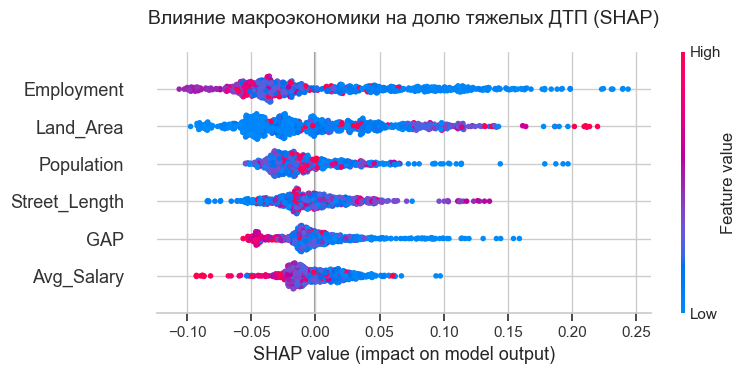

In [22]:
explainer_macro = shap.TreeExplainer(model_macro)

shap_values_macro = explainer_macro.shap_values(X)

plt.figure(figsize=(10, 8))
plt.title("Влияние макроэкономики на долю тяжелых ДТП (SHAP)", fontsize=14, pad=20)
shap.summary_plot(shap_values_macro, X, show=False)
plt.tight_layout()
plt.show()

In [24]:
shap_sum = np.abs(shap_values_macro).mean(axis=0)
importance_df_shap = pd.DataFrame([X.columns.tolist(), shap_sum.tolist()]).T
importance_df_shap.columns = ['Feature', 'SHAP_Importance']
importance_df_shap = importance_df_shap.sort_values('SHAP_Importance', ascending=False)

print("SHAP")
print(importance_df_shap.to_string(index=False))

SHAP
      Feature SHAP_Importance
   Employment        0.055529
    Land_Area        0.046091
   Population        0.024904
Street_Length        0.022506
          GAP        0.021164
   Avg_Salary        0.017716


In [26]:
from linearmodels.panel import PanelOLS

df_panel = df.copy()

df_panel['Employment_Rate'] = df_panel['Employment'] / df_panel['Population']
df_panel['log_Salary'] = np.log(df_panel['Avg_Salary'] + 1)

df_panel = df_panel.set_index(['municipality', 'year'])

formula_final = 'dtp_severe_share ~ 1 + log_Salary + Employment_Rate + EntityEffects'

model_final = PanelOLS.from_formula(formula_final, data=df_panel)
res_final = model_final.fit(cov_type='robust')

print(res_final.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       dtp_severe_share   R-squared:                        0.0389
Estimator:                   PanelOLS   R-squared (Between):             -0.0237
No. Observations:                 862   R-squared (Within):               0.0389
Date:                 Вт, апр 07 2026   R-squared (Overall):             -0.0110
Time:                        17:03:21   Log-likelihood                    953.14
Cov. Estimator:                Robust                                           
                                        F-statistic:                      15.458
Entities:                          96   P-value                           0.0000
Avg Obs:                       8.9792   Distribution:                   F(2,764)
Min Obs:                       7.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             14.970
                            